# Rolling analysis of Real US yields vs Gold returns

## Question
Do changes real yields explain gold returns better than nominal yields?

## Hypothesis
Change in real yield shows higher r^2 values in a rolling linear regression against gold returns when compared to a rolling linear regression for nominal yields

In [19]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
from src.rolling_regression import time_rolling_regression

comparison = pd.read_csv('../data/processed/full_table.csv',index_col =0, parse_dates = True)

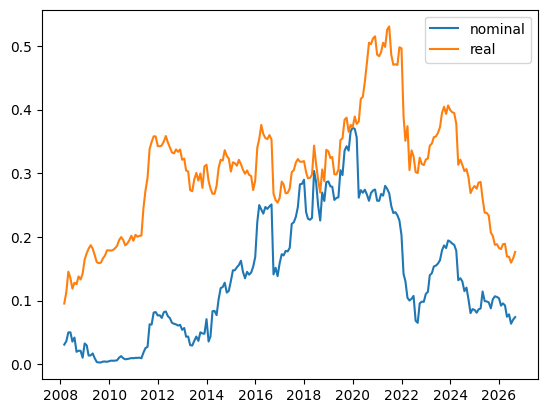

In [20]:
#Rolling linear regregression
time_frame = pd.DateOffset(years = 5)

real_coeffs, real_intercepts, real_r2score = time_rolling_regression(comparison, time_frame, 'Real Yield (bp Change)', 'Gold Price (% Change)')
nominal_coeffs, nominal_intercepts, nominal_r2score = time_rolling_regression(comparison, time_frame,'US10Y Yield (bp Change)', 'Gold Price (% Change)')

#Plotting the graphs
x_dates = pd.date_range(comparison.first_valid_index()+time_frame, comparison.index[-1], freq = 'ME').to_frame()
nominalvsreal_r2 = pd.DataFrame({'nominal_r2':nominal_r2score, 'real_r2':real_r2score},columns = ['nominal_r2','real_r2'])

plt.plot(x_dates,nominalvsreal_r2,label = ['nominal','real'])
plt.legend()

#R2 value for nominal and real yields when compared to gold with linear regression

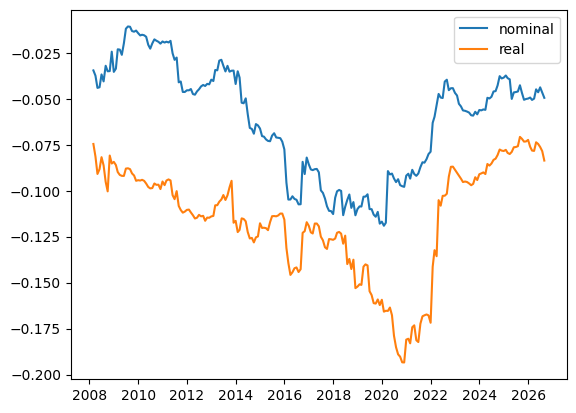

In [21]:
nominalvsreal_coeffs = pd.DataFrame({'nominal_coeffs':nominal_coeffs, 'real_coeffs':real_coeffs},columns = ['nominal_coeffs','real_coeffs'])
plt.plot(x_dates,nominalvsreal_coeffs,label = ['nominal','real'])
plt.legend()

#% change in gold per increase in basis point in both nominal and real yields